# Comprehensive Social Media Sentiment Analysis Pipeline

## Phase 1: Problem Definition & Setup

In [2]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import Counter, defaultdict
import re
import string
from typing import List, Dict, Tuple, Optional
import logging

In [ ]:
# !pip install nltk textstat spacy emoji

In [3]:
# Text processing
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
import textstat
import spacy
import emoji

In [4]:
# Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB

In [5]:
# Imbalanced learning
from imblearn.over_sampling import SMOTE

In [ ]:
# Deep Learning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from tqdm import tqdm

/Users/yifeishi/Desktop/DS Projects/Sentiment_Analysis/sentimen_analysis_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# Visualization and model interpretation
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud

In [8]:
# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [9]:
# Download required NLTK data
nltk.download('vader_lexicon', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

True

In [10]:
# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

In [11]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

In [12]:
# Global configuration
CONFIG = {
    'random_state': 42,
    'test_size': 0.2,
    'val_size': 0.2,
    'cv_folds': 5,
    'max_features': 1000,
    'min_class_samples': 10, # Increased from 5 for consolidated groups
    'sentiment_threshold': 0.1
}

In [13]:
# set not limit on display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## Phase 2: Data Loading & Initial Cleaning

In [14]:
# Load and initial data inspection
def load_and_inspect_data(file_path: str) -> pd.DataFrame:
    """Load data and perform initial inspection"""
    try:
        df = pd.read_csv(file_path)
        
        print(f"Dataset shape: {df.shape}")
        print(f"Columns: {list(df.columns)}")
        print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
        
        # Display basic info
        print("\n" + "="*50)
        print("DATASET OVERVIEW")
        print("="*50)
        df.info()
        
        return df
    except Exception as e:
        logger.error(f"Error loading data: {e}")
        return None

In [15]:
df = load_and_inspect_data('sentimentdataset.csv')
df.head()

Dataset shape: (732, 15)
Columns: ['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']
Memory usage: 0.42 MB

DATASET OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day       

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


Two columns are the same as index, they need to be removed

In [16]:
df.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'], inplace=True)
df.head()

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [17]:
# Data quality assessment function
def assess_data_quality(df: pd.DataFrame) -> Dict:
    """Comprehensive data quality assessment"""
    quality_report = {}
    
    print("DATA QUALITY ASSESSMENT")
    print("="*50)
    
    # Missing values analysis
    missing_analysis = df.isnull().sum()
    missing_pct = (missing_analysis / len(df)) * 100
    
    quality_report['missing_values'] = {
        'counts': missing_analysis.to_dict(),
        'percentages': missing_pct.to_dict()
    }
    
    print("Missing Values:")
    for col, count in missing_analysis.items():
        if count > 0:
            print(f"   {col}: {count} ({missing_pct[col]:.2f}%)")
    
    # Duplicate analysis
    duplicates = df.duplicated().sum()
    quality_report['duplicates'] = duplicates
    print(f"\nDuplicates: {duplicates} ({duplicates/len(df)*100:.2f}%)")
    
    # Text column analysis
    if 'Text' in df.columns:
        text_stats = {
            'empty_texts': df['Text'].isna().sum(),
            'avg_length': df['Text'].str.len().mean(),
            'min_length': df['Text'].str.len().min(),
            'max_length': df['Text'].str.len().max()
        }
        quality_report['text_stats'] = text_stats
        
        print(f"\nText Statistics:")
        print(f"   Empty texts: {text_stats['empty_texts']}")
        print(f"   Average length: {text_stats['avg_length']:.1f} characters")
        print(f"   Length range: {text_stats['min_length']} - {text_stats['max_length']}")
    
    # Sentiment distribution analysis
    if 'Sentiment' in df.columns:
        sentiment_counts = df['Sentiment'].value_counts()
        quality_report['sentiment_distribution'] = sentiment_counts.to_dict()
        
        print(f"\nSentiment Distribution:")
        print(f"   Total classes: {len(sentiment_counts)}")
        print(f"   Most common: {sentiment_counts.index[0]} ({sentiment_counts.iloc[0]})")
        print(f"   Least common: {sentiment_counts.index[-1]} ({sentiment_counts.iloc[-1]})")
        
        # Class imbalance assessment
        imbalance_ratio = sentiment_counts.max() / sentiment_counts.min()
        quality_report['class_imbalance_ratio'] = imbalance_ratio
        print(f"   Imbalance ratio: {imbalance_ratio:.2f}")
    
    return quality_report

In [18]:
quality_report = assess_data_quality(df)

DATA QUALITY ASSESSMENT
Missing Values:

Duplicates: 20 (2.73%)

Text Statistics:
   Empty texts: 0
   Average length: 87.6 characters
   Length range: 50 - 157

Sentiment Distribution:
   Total classes: 279
   Most common:  Positive   (44)
   Least common:  Elegance  (1)
   Imbalance ratio: 44.00


In [19]:
df['Sentiment'].value_counts()

Sentiment
Positive                 44
Joy                      42
Excitement               32
Neutral                  14
Contentment              14
Happy                    14
Hopeful                   9
Sad                       9
Gratitude                 9
Curiosity                 8
Embarrassed               8
Loneliness                7
Elation                   6
Bad                       6
Despair                   6
Hate                      6
Playful                   6
Gratitude                 5
Curiosity                 5
Enthusiasm                5
Inspired                  5
Empowerment               5
Contentment               5
Serenity                  5
Determination             5
Acceptance                5
Ambivalence               5
Nostalgia                 5
Melancholy                5
Numbness                  5
Confusion                 5
Serenity                  5
Indifference              5
Frustrated                5
Bitterness                5
Euphoria  

Noticed there are duplicated sentiments, need to trim for accuracy.

In [20]:
df['Platform'].value_counts()

Platform
Instagram     258
Facebook      231
Twitter       128
Twitter       115
Name: count, dtype: int64

Same issue with column 'Platform', need to trim as well.

In [21]:
df['Country'].value_counts()

Country
 USA                    59
 USA                    55
 UK                     49
 Canada                 44
 Australia              41
 Canada                 34
 UK                     33
 India                  21
 USA                    20
 Canada                 17
 UK                     13
 Australia              12
 USA                    12
 Brazil                 11
 India                  11
 USA                    10
 France                 10
 India                  10
 Japan                  10
 Canada                 10
 UK                      9
 USA                     9
USA                      9
 Germany                 9
 Italy                   8
 India                   8
 UK                      8
 UK                      7
 Canada                  7
 Canada                  6
 Canada                  6
 Australia               6
 UK                      6
 India                   5
 Australia               5
 India                   5
 Australia          

The same standardizarion goes to 'Country' column as well.

In [22]:
df_standardized = df.copy()

In [23]:
# List of categorical columns to standardize
categorical_cols = ['Sentiment', 'Platform', 'Country']

for col in categorical_cols:
    if col in df_standardized.columns:
        print(f"   Standardizing {col} column...")
        original_unique = df_standardized[col].nunique()
        
        # Convert to lowercase and strip whitespace
        df_standardized[col] = df_standardized[col].str.lower().str.strip()
        
        standardized_unique = df_standardized[col].nunique()
        
        if original_unique > standardized_unique:
            print(f"      Merged {original_unique - standardized_unique} duplicate entries")
        
        print(f"      Final unique values: {standardized_unique}")

   Standardizing Sentiment column...
      Merged 88 duplicate entries
      Final unique values: 191
   Standardizing Platform column...
      Merged 1 duplicate entries
      Final unique values: 3
   Standardizing Country column...
      Merged 82 duplicate entries
      Final unique values: 33


In [24]:
# Remove duplicates
initial_shape = df_standardized.shape[0]
df_standardized = df_standardized.drop_duplicates()
final_shape = df_standardized.shape[0]
if initial_shape > final_shape:
    print(f"   Removed {initial_shape - final_shape} duplicate rows")

   Removed 21 duplicate rows


## Phase 3: Text Preprocessing

In [25]:
# Initialize required components
analyzer = SentimentIntensityAnalyzer()
lemmatizer = WordNetLemmatizer()

In [26]:
# Define constants
PRESERVE_PUNCT = set('!?')
NEGATIONS = {'not', 'no', 'never', 'neither', 'nobody', 'nothing', 
            'nowhere', 'none', "don't", "doesn't", "didn't", "won't", 
            "wouldn't", "shouldn't", "couldn't", "can't", "isn't", 
            "aren't", "wasn't", "weren't"}
INTENSIFIERS = {'very', 'extremely', 'incredibly', 'absolutely', 
               'completely', 'totally', 'really', 'quite', 'rather',
               'somewhat', 'slightly', 'barely', 'hardly'}

In [27]:
def convert_emojis_to_text(text):
    """Convert emojis to text descriptions"""
    if pd.isna(text):
        return text
    return emoji.demojize(text, delimiters=(" EMOJI_"))

In [28]:
def handle_repeated_characters(text):
    """Normalize repeated alphabetic characters while preserving intensity"""
    if pd.isna(text):
        return text
    # Only match repeated alphabetic characters (3 or more)
    pattern = r'([a-zA-Z])\1{2,}'
    def replace_repeated(match):
        char = match.group(1)
        return char + '_INTENSE'
    return re.sub(pattern, replace_repeated, text)

In [29]:
def preserve_caps_patterns(text):
    """Preserve ALL CAPS as intensity markers"""
    if pd.isna(text):
        return text
    words = text.split()
    processed_words = []
    for word in words:
        # Only process words that are truly ALL CAPS (length > 1 and all alphabetic)
        if word.isupper() and len(word) > 1 and word.isalpha():
            processed_words.append(word.lower() + '_CAPS')
        else:
            processed_words.append(word)
    return ' '.join(processed_words)

In [30]:
def handle_negations(text):
    """Mark tokens following negations and remove the negation word"""
    if pd.isna(text):
        return text
    words = text.split()
    processed_words = []
    negate_next = False

    for word in words:
        if word.lower() in NEGATIONS:
            negate_next = True
            continue  # skip appending the negation word itself
        elif negate_next and word.isalpha():
            processed_words.append(f"NOT_{word}")
            negate_next = False
        else:
            processed_words.append(word)
            if word in ['.', '!', '?', ',']:
                negate_next = False

    return ' '.join(processed_words)

In [31]:
def preserve_sentiment_punctuation(text):
    """Preserve and normalize sentiment-bearing punctuation, ensuring separation from words"""
    if pd.isna(text):
        return text
    # Add space before and after ! and ? to ensure separation
    text = re.sub(r'([!?])', r' \1 ', text)
    # Multiple exclamation marks
    text = re.sub(r'!{2,}', ' MULTI_EXCLAIM ', text)
    # Multiple question marks
    text = re.sub(r'\?{2,}', ' MULTI_QUESTION ', text)
    # Ellipsis (three or more dots)
    text = re.sub(r'\.{3,}', ' ELLIPSIS ', text)
    # Normalize whitespace
    text = ' '.join(text.split())
    return text

In [32]:
def advanced_text_cleaning(text):
    """Comprehensive preprocessing pipeline"""
    if pd.isna(text) or text == '':
        return ''
    
    text = str(text)
    
    # Step 1: Convert emojis
    text = convert_emojis_to_text(text)
    
    # Step 2: Handle repeated characters
    text = handle_repeated_characters(text)
    
    # Step 3: Preserve caps patterns
    text = preserve_caps_patterns(text)
    
    # Step 4: Preserve sentiment punctuation
    text = preserve_sentiment_punctuation(text)
    
    # Step 5: Handle negations
    text = handle_negations(text)
    
    # Step 6: Remove other punctuation but keep preserved ones and underscores
    chars_to_remove = string.punctuation.replace('_', '')  # keep underscore
    for char in '!?':
        chars_to_remove = chars_to_remove.replace(char, '')
    
    for char in chars_to_remove:
        text = text.replace(char, ' ')

    # Step 7: Normalize whitespace
    text = ' '.join(text.split())
    
    # Step 8: Light lemmatization (preserve our special markers)
    words = text.split()
    lemmatized_words = []
    for word in words:
        if '_' in word or word.isupper():  # Preserve our markers
            lemmatized_words.append(word.lower())
        else:
            lemmatized_words.append(lemmatizer.lemmatize(word.lower()))
    
    return ' '.join(lemmatized_words)

In [33]:
df_preprocessed = df_standardized.copy()

In [34]:
# Apply advanced preprocessing
print("Applying advanced text preprocessing...")
df_preprocessed['Enhanced_Text'] = df_preprocessed['Text'].apply(advanced_text_cleaning)

Applying advanced text preprocessing...


In [35]:
# compare the text and enhance text, sample out records
pd.set_option('display.max_colwidth', None)
df_preprocessed[['Text', 'Enhanced_Text']].head(10)

,Text,Enhanced_Text
0,Enjoying a beautiful day at the park!,enjoying a beautiful day at the park !
1,Traffic was terrible this morning.,traffic wa terrible this morning
2,Just finished an amazing workout! 💪,just finished an amazing workout ! flexed_bicepse
3,Excited about the upcoming weekend getaway!,excited about the upcoming weekend getaway !
4,Trying out a new recipe for dinner tonight.,trying out a new recipe for dinner tonight
5,Feeling grateful for the little things in life.,feeling grateful for the little thing in life
6,Rainy days call for cozy blankets and hot cocoa.,rainy day call for cozy blanket and hot cocoa
7,The new movie release is a must-watch!,the new movie release is a must watch !
8,Political discussions heating up on the timeline.,political discussion heating up on the timeline
9,Missing summer vibes and beach days.,missing summer vibe and beach day


In [36]:
# counts distribution of tokens in the enhanced text
token_counts = df_preprocessed['Enhanced_Text'].str.split().apply(len)
# find max, min, and average token lengths for enhanced text
max_tokens = token_counts.max()
min_tokens = token_counts.min()
avg_tokens = token_counts.mean()
print(f"   Average tokens per text: {avg_tokens:.1f}")
print(f"   Max tokens: {max_tokens}")
print(f"   Min tokens: {min_tokens}")

   Average tokens per text: 13.3
   Max tokens: 26
   Min tokens: 4


We can see the average tokens per text is less than 20 words, and the texts with max tokens and min tokens are not steongly deviated from average lengths of tokens. Since we are preprocessing social media posts, we are dealing with shorter texts with relative smaller average numbers of tokens per text and smaller variance in token lengths.

## Phase 4: Sentiment Consolidation

In [ ]:
# put all sentiments in a list
sentiments = df['Sentiment'].value_counts().index.tolist()

In [ ]:
print(sentiments)

In [38]:
sentiments_grouped = {
        'positive_high': ['joy', 'happiness', 'happy', 'elation', 'euphoria', 'ecstasy', 'bliss', 
                         'excitement', 'enthusiasm', 'thrill', 'exhilaration', 'anticipation', 
                         'zest', 'energy', 'adrenaline', 'adventure', 'overjoyed', 'festivejoy',
                         'playful', 'playfuljoy', 'joyfulreunion', 'breakthrough', 'triumph',
                         'thrilling journey', 'amusement', 'enjoyment', 'whimsy', 'mischievous'],
        
        'positive_calm': ['contentment', 'serenity', 'tranquility', 'calmness', 'acceptance', 
                         'harmony', 'fulfillment', 'satisfaction', 'peace', 'mindfulness',
                         'inner journey', 'reflection', 'contemplation', 'pensive', 'rejuvenation'],
        
        'love_connection': ['love', 'affection', 'adoration', 'tenderness', 'romance', 'heartwarming',
                           'compassionate', 'compassion', 'empathetic', 'kindness', 'kind',
                           'friendship', 'connection', 'touched', 'gratitude', 'grateful',
                           'appreciation', 'blessed'],
        
        'wonder_admiration': ['admiration', 'respect', 'reverence', 'awe', 'wonder', 'amazement',
                             'wonderment', 'marvel', 'surprise', 'astonishment', 'inspiration',
                             'inspired', 'creativity', 'enchantment', 'captivation', 'mesmerizing',
                             'dazzle', 'radiance', 'elegance', 'celestial wonder', "nature's beauty"],
        
        'confidence_pride': ['pride', 'proud', 'accomplishment', 'success', 'confidence', 'confident',
                            'determination', 'resilience', 'motivation', 'empowerment', 'optimism',
                            'hope', 'hopeful', 'positivity', 'positive', 'free-spirited', 'freedom'],
        
        'curiosity_exploration': ['curiosity', 'interest', 'intrigue', 'exploration', 'spark',
                                 'adventure', 'journey', 'imagination', 'creative inspiration',
                                 'dream chaser', 'artistic burst', 'runway creativity'],
        
        'sadness_grief': ['sadness', 'sorrow', 'grief', 'melancholy', 'despair', 'depression',
                         'heartbreak', 'heartache', 'loss', 'lostlove', 'loneliness', 'isolation',
                         'solitude', 'desolation', 'suffering', 'darkness', 'exhaustion',
                         'desperation', 'misery', 'gloom'],
        
        'anger_frustration': ['anger', 'rage', 'fury', 'irritation', 'annoyance', 'frustrated',
                             'frustration', 'hate', 'bitterness', 'bitter', 'resentment',
                             'betrayal', 'devastated', 'jealous', 'jealousy', 'envious', 'envy'],
        
        'negative_complex': ['fear', 'anxiety', 'worry', 'fearful', 'apprehensive', 'intimidation',
                            'helplessness', 'shame', 'guilt', 'embarrassed', 'regret', 'disappointment',
                            'disappointed', 'disgust', 'confusion', 'overwhelmed', 'emotional storm',
                            'pressure', 'numbness', 'ambivalence', 'vulnerability', 'bad', 'negative']
    }

In [39]:
# now create a mapping of sentiments to their categories
sentiment_to_category = {}
for category, words in sentiments_grouped.items():
    for word in words:
        sentiment_to_category[word] = category

In [40]:
def find_best_group(sentiment, emotion_groups, sentiment_mapping):
    """Find the best group for a sentiment label"""
    sentiment = sentiment.lower().strip()
    
    # Direct exact match
    if sentiment in sentiment_mapping:
        return sentiment_mapping[sentiment]
    
    # Direct partial match for compound emotions
    for group, emotions in emotion_groups.items():
        for emotion in emotions:
            if emotion == sentiment:  # Exact match only
                return group

In [41]:
df_analyzed = df_preprocessed.copy()

In [42]:
# Show original distribution
original_counts = df_analyzed['Sentiment'].value_counts()
print(f"Original sentiment categories: {len(original_counts)}")

Original sentiment categories: 191


In [43]:
# Apply consolidation
df_analyzed['Consolidated_Sentiment'] = df_analyzed['Sentiment'].apply(
	lambda x: find_best_group(x, sentiments_grouped, sentiment_to_category)
)

In [44]:
# Show new distribution
consolidated_counts = df_analyzed['Consolidated_Sentiment'].value_counts()
print(f"Consolidated sentiment categories: {len(consolidated_counts)}")
print(f"Data size maintained: {len(df_analyzed)}")

Consolidated sentiment categories: 9
Data size maintained: 711


In [45]:
print("\nConsolidated sentiment distribution:")
for sentiment, count in consolidated_counts.items():
    print(f"   {sentiment}: {count} samples ({count/len(df_analyzed)*100:.1f}%)")


Consolidated sentiment distribution:
   positive_high: 152 samples (21.4%)
   confidence_pride: 92 samples (12.9%)
   negative_complex: 74 samples (10.4%)
   positive_calm: 66 samples (9.3%)
   sadness_grief: 56 samples (7.9%)
   wonder_admiration: 53 samples (7.5%)
   love_connection: 51 samples (7.2%)
   anger_frustration: 49 samples (6.9%)
   curiosity_exploration: 27 samples (3.8%)


In [46]:
# see if there is any row without consolidated sentiments (%)
missing_consolidated = df_analyzed[df_analyzed['Consolidated_Sentiment'].isnull()]
print(f"Percentages of rows without consolidated sentiments: {len(missing_consolidated) / len(df_analyzed) * 100:.1f}%")

Percentages of rows without consolidated sentiments: 12.8%


Based on the class distribution of the consolidated sentiments, we can see there is a major issue of class imbalance, and there is a high percentage of missing labels. Here we can introduce vader sentiment analyzer to analyze the texts and categorize them by sentiment nature.

In [47]:
sentiment_scores = []
for sentiment in df_analyzed['Sentiment']:
    scores = analyzer.polarity_scores(sentiment)
    sentiment_scores.append(scores['compound'])

df_analyzed['Sentiment_Score'] = sentiment_scores

In [48]:
text_sentiment_scores = []
for text_sentiment in df_analyzed['Enhanced_Text']:
    scores = analyzer.polarity_scores(text_sentiment)
    text_sentiment_scores.append(scores['compound'])

df_analyzed['Text_Sentiment_Score'] = text_sentiment_scores

In [49]:
df_analyzed.head()

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,Enhanced_Text,Consolidated_Sentiment,Sentiment_Score,Text_Sentiment_Score
0,Enjoying a beautiful day at the park!,positive,2023-01-15 12:30:00,User123,twitter,#Nature #Park,15.0,30.0,usa,2023,1,15,12,enjoying a beautiful day at the park !,confidence_pride,0.5574,0.8221
1,Traffic was terrible this morning.,negative,2023-01-15 08:45:00,CommuterX,twitter,#Traffic #Morning,5.0,10.0,canada,2023,1,15,8,traffic wa terrible this morning,negative_complex,-0.5719,-0.4767
2,Just finished an amazing workout! 💪,positive,2023-01-15 15:45:00,FitnessFan,instagram,#Fitness #Workout,20.0,40.0,usa,2023,1,15,15,just finished an amazing workout ! flexed_bicepse,confidence_pride,0.5574,0.6239
3,Excited about the upcoming weekend getaway!,positive,2023-01-15 18:20:00,AdventureX,facebook,#Travel #Adventure,8.0,15.0,uk,2023,1,15,18,excited about the upcoming weekend getaway !,confidence_pride,0.5574,0.4003
4,Trying out a new recipe for dinner tonight.,neutral,2023-01-15 19:55:00,ChefCook,instagram,#Cooking #Food,12.0,25.0,australia,2023,1,15,19,trying out a new recipe for dinner tonight,None,0.0000,0.0000


In [50]:
# Categorize sentiments based on VADER compound score
df_analyzed['Sentiment_Nature'] = df_analyzed['Sentiment_Score'].apply(
    lambda x: 'positive' if x >= 0.05 else 'negative' if x <= -0.05 else 'neutral'
)
df_analyzed.head()

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,Enhanced_Text,Consolidated_Sentiment,Sentiment_Score,Text_Sentiment_Score,Sentiment_Nature
0,Enjoying a beautiful day at the park!,positive,2023-01-15 12:30:00,User123,twitter,#Nature #Park,15.0,30.0,usa,2023,1,15,12,enjoying a beautiful day at the park !,confidence_pride,0.5574,0.8221,positive
1,Traffic was terrible this morning.,negative,2023-01-15 08:45:00,CommuterX,twitter,#Traffic #Morning,5.0,10.0,canada,2023,1,15,8,traffic wa terrible this morning,negative_complex,-0.5719,-0.4767,negative
2,Just finished an amazing workout! 💪,positive,2023-01-15 15:45:00,FitnessFan,instagram,#Fitness #Workout,20.0,40.0,usa,2023,1,15,15,just finished an amazing workout ! flexed_bicepse,confidence_pride,0.5574,0.6239,positive
3,Excited about the upcoming weekend getaway!,positive,2023-01-15 18:20:00,AdventureX,facebook,#Travel #Adventure,8.0,15.0,uk,2023,1,15,18,excited about the upcoming weekend getaway !,confidence_pride,0.5574,0.4003,positive
4,Trying out a new recipe for dinner tonight.,neutral,2023-01-15 19:55:00,ChefCook,instagram,#Cooking #Food,12.0,25.0,australia,2023,1,15,19,trying out a new recipe for dinner tonight,None,0.0000,0.0000,neutral


In [51]:
print("Sentiment nature distribution based on VADER analysis of labels:")
nature_dist = df_analyzed['Sentiment_Nature'].value_counts()
for nature, count in nature_dist.items():
    print(f"   {nature}: {count} samples ({count/len(df_analyzed)*100:.1f}%)")

Sentiment nature distribution based on VADER analysis of labels:
   positive: 360 samples (50.6%)
   negative: 182 samples (25.6%)
   neutral: 169 samples (23.8%)


In terms of distribution of sentiment nature, we did not see a strong class imbalance,and this ratio can be used for upsampling fot sentiment classification.

In [52]:
df_analyzed['Text_Sentiment_Nature'] = df_analyzed['Text_Sentiment_Score'].apply(
    lambda x: 'positive' if x >= 0.05 else 'negative' if x <= -0.05 else 'neutral'
)
df_analyzed.head()

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,Enhanced_Text,Consolidated_Sentiment,Sentiment_Score,Text_Sentiment_Score,Sentiment_Nature,Text_Sentiment_Nature
0,Enjoying a beautiful day at the park!,positive,2023-01-15 12:30:00,User123,twitter,#Nature #Park,15.0,30.0,usa,2023,1,15,12,enjoying a beautiful day at the park !,confidence_pride,0.5574,0.8221,positive,positive
1,Traffic was terrible this morning.,negative,2023-01-15 08:45:00,CommuterX,twitter,#Traffic #Morning,5.0,10.0,canada,2023,1,15,8,traffic wa terrible this morning,negative_complex,-0.5719,-0.4767,negative,negative
2,Just finished an amazing workout! 💪,positive,2023-01-15 15:45:00,FitnessFan,instagram,#Fitness #Workout,20.0,40.0,usa,2023,1,15,15,just finished an amazing workout ! flexed_bicepse,confidence_pride,0.5574,0.6239,positive,positive
3,Excited about the upcoming weekend getaway!,positive,2023-01-15 18:20:00,AdventureX,facebook,#Travel #Adventure,8.0,15.0,uk,2023,1,15,18,excited about the upcoming weekend getaway !,confidence_pride,0.5574,0.4003,positive,positive
4,Trying out a new recipe for dinner tonight.,neutral,2023-01-15 19:55:00,ChefCook,instagram,#Cooking #Food,12.0,25.0,australia,2023,1,15,19,trying out a new recipe for dinner tonight,None,0.0000,0.0000,neutral,neutral


In [53]:
print("Text sentiment nature distribution based on VADER analysis of labels:")
text_nature_dist = df_analyzed['Text_Sentiment_Nature'].value_counts()
for nature, count in text_nature_dist.items():
    print(f"   {nature}: {count} samples ({count/len(df_analyzed)*100:.1f}%)")

Text sentiment nature distribution based on VADER analysis of labels:
   positive: 442 samples (62.2%)
   negative: 188 samples (26.4%)
   neutral: 81 samples (11.4%)


In terms of distribution of text sentiment nature, there is an issue class imbalance and misalignment between texts and labeled sentiments.

In [54]:
# Compare how many rows have the same sentiment nature based on texts and labeled sentiments
print("COMPARING LABEL VS TEXT SENTIMENT AGREEMENT")
print("="*50)

correct_label = df_analyzed[df_analyzed['Sentiment_Nature'] == df_analyzed['Text_Sentiment_Nature']].shape[0]

# calculate the percentage of correct labels
total_rows = df_analyzed.shape[0]
correct_label_percentage = (correct_label / total_rows) * 100

print(f"   Sentiment nature agreement: {correct_label_percentage:.1f}%")
print(f"   Correct labels: {correct_label} out of {total_rows} total samples")

COMPARING LABEL VS TEXT SENTIMENT AGREEMENT
   Sentiment nature agreement: 71.3%
   Correct labels: 507 out of 711 total samples


There is only 71.3% sentiments that are correctedly labeled. 
<br><br>
Since text is the actual content I will be classifying in production, consider the VADER-analyzed sentiment as ground truth and treat inconsistent labels as noise. 

For rows without consolidated sentiments, we can fill in with their sentiment nature by further classification.

In [56]:
df_analyzed['Consolidated_Sentiment'] = df_analyzed.apply(
    lambda row: row['Text_Sentiment_Nature'] if pd.isna(row['Consolidated_Sentiment']) else row['Consolidated_Sentiment'],
    axis=1
)
df_analyzed.head()

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,Enhanced_Text,Consolidated_Sentiment,Sentiment_Score,Text_Sentiment_Score,Sentiment_Nature,Text_Sentiment_Nature
0,Enjoying a beautiful day at the park!,positive,2023-01-15 12:30:00,User123,twitter,#Nature #Park,15.0,30.0,usa,2023,1,15,12,enjoying a beautiful day at the park !,confidence_pride,0.5574,0.8221,positive,positive
1,Traffic was terrible this morning.,negative,2023-01-15 08:45:00,CommuterX,twitter,#Traffic #Morning,5.0,10.0,canada,2023,1,15,8,traffic wa terrible this morning,negative_complex,-0.5719,-0.4767,negative,negative
2,Just finished an amazing workout! 💪,positive,2023-01-15 15:45:00,FitnessFan,instagram,#Fitness #Workout,20.0,40.0,usa,2023,1,15,15,just finished an amazing workout ! flexed_bicepse,confidence_pride,0.5574,0.6239,positive,positive
3,Excited about the upcoming weekend getaway!,positive,2023-01-15 18:20:00,AdventureX,facebook,#Travel #Adventure,8.0,15.0,uk,2023,1,15,18,excited about the upcoming weekend getaway !,confidence_pride,0.5574,0.4003,positive,positive
4,Trying out a new recipe for dinner tonight.,neutral,2023-01-15 19:55:00,ChefCook,instagram,#Cooking #Food,12.0,25.0,australia,2023,1,15,19,trying out a new recipe for dinner tonight,neutral,0.0000,0.0000,neutral,neutral


In [57]:
# now see if there is any row without consolidated sentiments (%)
missing_consolidated = df_analyzed[df_analyzed['Consolidated_Sentiment'].isnull()]
print(f"Percentages of rows without consolidated sentiments: {len(missing_consolidated) / len(df_analyzed) * 100:.1f}%")

Percentages of rows without consolidated sentiments: 0.0%


# Phase 5: Comprehensive EDA 

COMPREHENSIVE EXPLORATORY DATA ANALYSIS


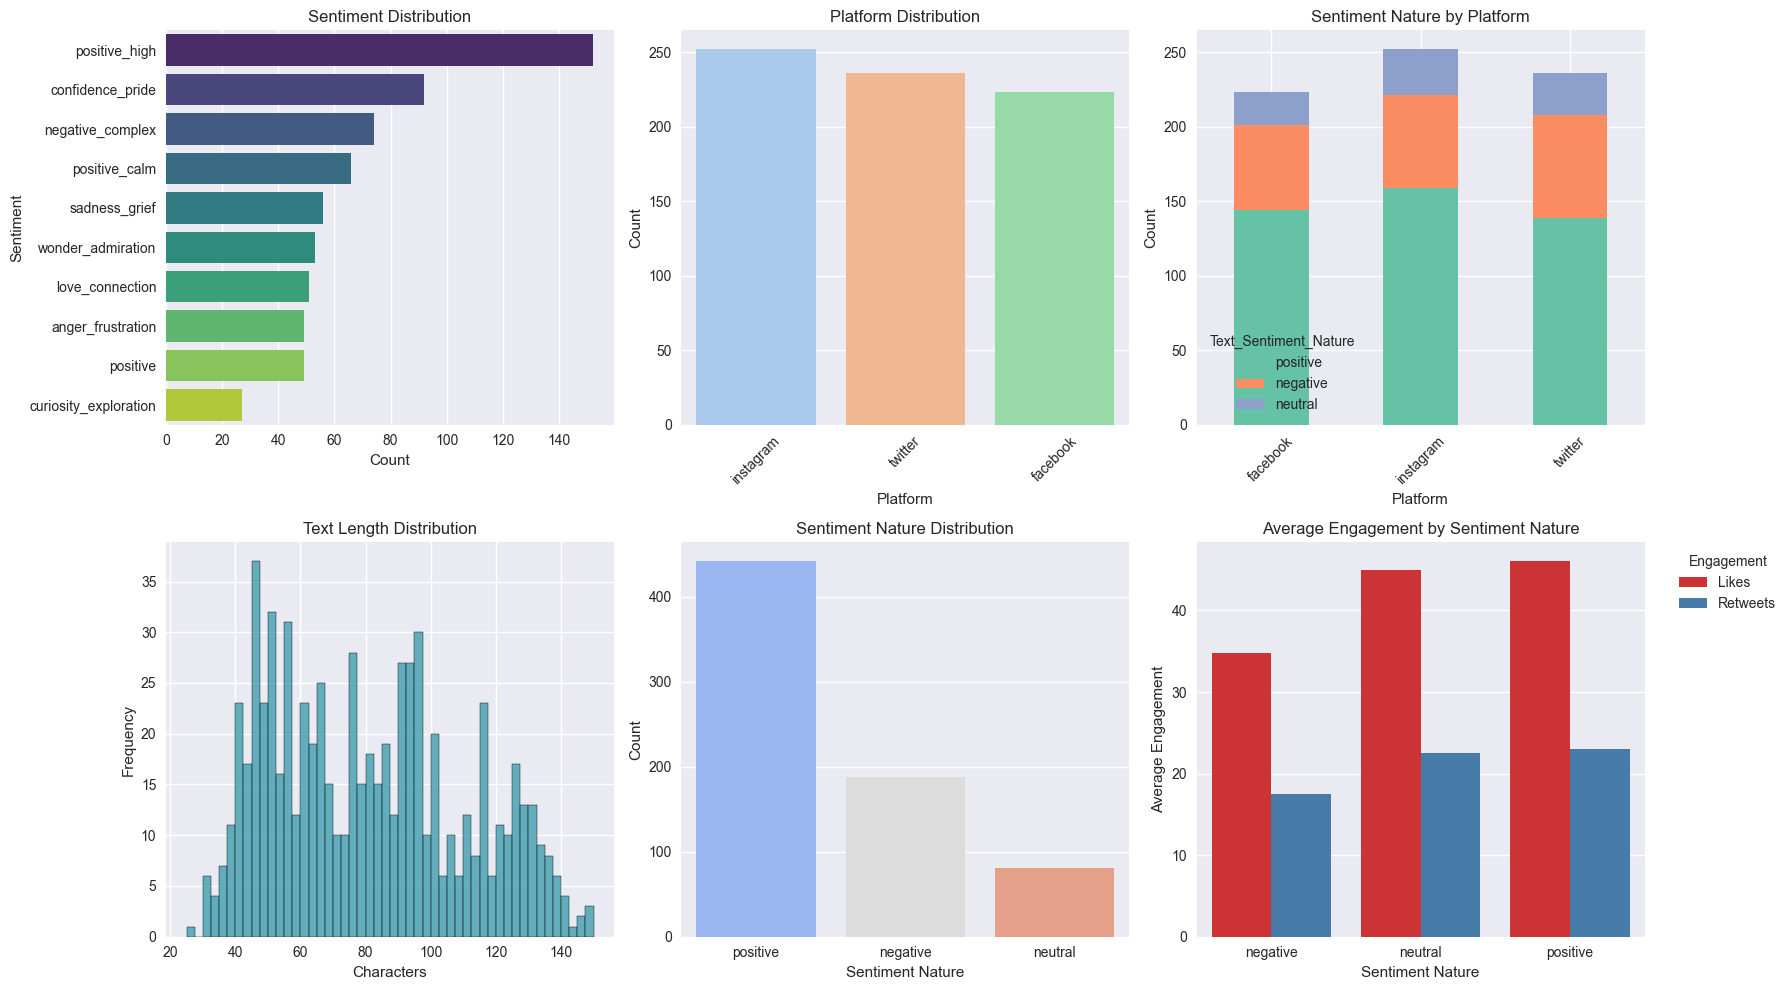

In [58]:
class ComprehensiveEDA:
    def __init__(self, df: pd.DataFrame):
        self.df = df

    def plot_sentiment_distribution(self, ax):
        sentiment_counts = self.df['Consolidated_Sentiment'].value_counts().head(10)
        sns.barplot(
            x=sentiment_counts.values, 
            y=sentiment_counts.index, 
            ax=ax, 
            palette="viridis"
        )
        ax.set_title('Sentiment Distribution')
        ax.set_xlabel('Count')
        ax.set_ylabel('Sentiment')

    def plot_platform_distribution(self, ax):
        platform_counts = self.df['Platform'].value_counts()
        sns.barplot(
            x=platform_counts.index, 
            y=platform_counts.values, 
            ax=ax, 
            palette="pastel"
        )
        ax.set_title('Platform Distribution')
        ax.set_xlabel('Platform')
        ax.set_ylabel('Count')
        ax.set_xticklabels(platform_counts.index, rotation=45)

    def plot_sentiment_by_platform(self, ax):
        platform_sentiment = pd.crosstab(self.df['Platform'], self.df['Text_Sentiment_Nature'])
        platform_sentiment = platform_sentiment[["positive", "negative", "neutral"]] if all(col in platform_sentiment.columns for col in ["positive", "negative", "neutral"]) else platform_sentiment
        platform_sentiment.plot(
            kind='bar', 
            stacked=True, 
            ax=ax, 
            color=sns.color_palette("Set2", n_colors=platform_sentiment.shape[1])
        )
        ax.set_title('Sentiment Nature by Platform')
        ax.set_xlabel('Platform')
        ax.set_ylabel('Count')
        ax.set_xticklabels(platform_sentiment.index, rotation=45)

    def plot_text_length_distribution(self, ax):
        text_lengths = self.df['Enhanced_Text'].str.len()
        sns.histplot(
            text_lengths, 
            bins=50, 
            ax=ax, 
            color=sns.color_palette("mako", as_cmap=True)(0.6)
        )
        ax.set_title('Text Length Distribution')
        ax.set_xlabel('Characters')
        ax.set_ylabel('Frequency')

    def plot_sentiment_nature_distribution(self, ax):
        nature_counts = self.df['Text_Sentiment_Nature'].value_counts()
        sns.barplot(
            x=nature_counts.index, 
            y=nature_counts.values, 
            ax=ax, 
            palette="coolwarm"
        )
        ax.set_title('Sentiment Nature Distribution')
        ax.set_xlabel('Sentiment Nature')
        ax.set_ylabel('Count')

    def plot_engagement_by_sentiment(self, ax):
        if 'Likes' in self.df.columns and 'Retweets' in self.df.columns:
            engagement_by_sentiment = self.df.groupby('Text_Sentiment_Nature')[['Likes', 'Retweets']].mean().reset_index()
            engagement_by_sentiment = engagement_by_sentiment.melt(id_vars='Text_Sentiment_Nature', var_name='Engagement', value_name='Average')
            sns.barplot(
                data=engagement_by_sentiment, 
                x='Text_Sentiment_Nature', 
                y='Average', 
                hue='Engagement', 
                ax=ax, 
                palette="Set1"
            )
            ax.set_title('Average Engagement by Sentiment Nature')
            ax.set_xlabel('Sentiment Nature')
            ax.set_ylabel('Average Engagement')
            ax.legend(title='Engagement', bbox_to_anchor=(1.05, 1), loc='upper left')
        else:
            ax.text(0.5, 0.5, 'No Likes/Retweets data', ha='center', va='center')
            ax.set_axis_off()

    def run(self):
        print("COMPREHENSIVE EXPLORATORY DATA ANALYSIS")
        print("="*60)
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        plot_methods = [
            self.plot_sentiment_distribution,
            self.plot_platform_distribution,
            self.plot_sentiment_by_platform,
            self.plot_text_length_distribution,
            self.plot_sentiment_nature_distribution,
            self.plot_engagement_by_sentiment
        ]
        axes = axes.flatten()
        for method, ax in zip(plot_methods, axes):
            method(ax)
        plt.tight_layout()
        plt.show()
        return {}

# Perform comprehensive EDA
eda = ComprehensiveEDA(df_analyzed)
eda_results = eda.run()

Based on the comprehensive EDA analysis, we can observe that:
1. 'Positive' constitutes over 50% of all sentiments nature across all platfoems, where top 1 consolidated sentiment is 'positive_high' exceeding counts of all other consolidated sentiments.
2. Sample posts on each platform are similar in sizes and sentimemnt nature contribution.
3. The text length distribution appears to be a bimodal distribution with peaks around 50 and 100 characters, showing two distinct modes rather than a single central tendency.
4. Social media posts generate more average likes than average restweets, with more engamenet for positive sentiments and less for negative sentiments.

## Phase 6: ML Model Development & Training

### Prepare data splits

In [113]:
# Step 1: Clean final dataset and prepare target
print("Step 1: Preparing final dataset...")
df_modeled = df_analyzed.dropna(subset=['Consolidated_Sentiment']).copy()
print(f"Final dataset size: {len(df_modeled)} samples")

Step 1: Preparing final dataset...
Final dataset size: 711 samples


In [114]:
# Step 2: Create data splits FIRST
print("Step 2: Creating data splits...")
target_labels = df_modeled['Consolidated_Sentiment']
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(target_labels)

Step 2: Creating data splits...


In [115]:
print(label_encoder.classes_)

['anger_frustration' 'confidence_pride' 'curiosity_exploration'
 'love_connection' 'negative' 'negative_complex' 'neutral' 'positive'
 'positive_calm' 'positive_high' 'sadness_grief' 'wonder_admiration']


In [116]:
X_train_idx, X_temp_idx, y_train, y_temp = train_test_split(
    df_modeled.index, y_encoded,
    test_size=0.4,  # 40% for validation + test
    random_state=CONFIG['random_state'],
    stratify=y_encoded
)

X_val_idx, X_test_idx, y_val, y_test = train_test_split(
    X_temp_idx, y_temp,
    test_size=0.5,  # Split the 40% equally between val and test
    random_state=CONFIG['random_state'],
    stratify=y_temp
)

In [117]:
print(f"   Train: {len(X_train_idx)} samples")
print(f"   Validation: {len(X_val_idx)} samples") 
print(f"   Test: {len(X_test_idx)} samples")
print(f"   Classes: {len(label_encoder.classes_)}")

   Train: 426 samples
   Validation: 142 samples
   Test: 143 samples
   Classes: 12


### Create text representations

We need two embedding methods because different algorithms have fundamentally different mathematical requirements: Naive Bayes expects discrete count data to calculate word probabilities within each class, while Logistic Regression and SVM perform better with TF-IDF's continuous, normalized features that emphasize distinctive terms and reduce the influence of common words.

In [118]:
# Step 3: Create text representations using ONLY training data
print("Step 3: Creating text representations...")
train_texts = df_modeled.loc[X_train_idx, 'Enhanced_Text'].fillna('').tolist()
val_texts = df_modeled.loc[X_val_idx, 'Enhanced_Text'].fillna('').tolist()
test_texts = df_modeled.loc[X_test_idx, 'Enhanced_Text'].fillna('').tolist()

Step 3: Creating text representations...


In [119]:
# 1. TF-IDF representation

tfidf_vectorizer = TfidfVectorizer(
    max_features=CONFIG['max_features'],
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.95,
    stop_words='english'
)

X_train_tfidf = tfidf_vectorizer.fit_transform(train_texts)
X_val_tfidf = tfidf_vectorizer.transform(val_texts)
X_test_tfidf = tfidf_vectorizer.transform(test_texts)

In [120]:
X_train_tfidf.shape, X_val_tfidf.shape, X_test_tfidf.shape

((426, 809), (142, 809), (143, 809))

In [121]:
# 2. Count vectorizer (for Naive Bayes)
# Count Vectorizer - FIT only on training data
count_vectorizer = CountVectorizer(
    max_features=CONFIG['max_features'],
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.95,
    stop_words='english'
)

X_train_count = count_vectorizer.fit_transform(train_texts)
X_val_count = count_vectorizer.transform(val_texts)
X_test_count = count_vectorizer.transform(test_texts)

In [122]:
X_train_count.shape, X_val_count.shape, X_test_count.shape

((426, 809), (142, 809), (143, 809))

In [123]:
print(f"   TF-IDF features shape: {X_train_tfidf.shape}")
print(f"   Count features shape: {X_train_count.shape}")

   TF-IDF features shape: (426, 809)
   Count features shape: (426, 809)


In [124]:
# Convert sparse matrices to dense for SMOTE
X_train_tfidf_dense = X_train_tfidf.toarray()
X_train_count_dense = X_train_count.toarray()

In [125]:
# Apply SMOTE with balanced sampling strategy
smote = SMOTE(random_state=CONFIG['random_state'], k_neighbors=3)

# SMOTE for TF-IDF data
X_train_tfidf_resampled, y_train_tfidf_resampled = smote.fit_resample(X_train_tfidf_dense, y_train)

# SMOTE for Count data  
X_train_count_resampled, y_train_count_resampled = smote.fit_resample(X_train_count_dense, y_train)

print(f"   Original training samples: {len(y_train)}")
print(f"   Resampled training samples: {len(y_train_tfidf_resampled)}")

   Original training samples: 426
   Resampled training samples: 1092


In [129]:
# Check class distribution after SMOTE
resampled_tfidf = Counter(y_train_tfidf_resampled)
print(f"   Resampled tf-idf-embedded class distribution:")
for class_idx, count in sorted(resampled_tfidf.items()):
    class_name = label_encoder.classes_[class_idx]
    print(f"      {class_name}: {count} samples")

resampled_count = Counter(y_train_count_resampled)
print(f"   Resampled count-embedded class distribution:")
for class_idx, count in sorted(resampled_count.items()):
    class_name = label_encoder.classes_[class_idx]
    print(f"      {class_name}: {count} samples")

   Resampled tf-idf-embedded class distribution:
      anger_frustration: 91 samples
      confidence_pride: 91 samples
      curiosity_exploration: 91 samples
      love_connection: 91 samples
      negative: 91 samples
      negative_complex: 91 samples
      neutral: 91 samples
      positive: 91 samples
      positive_calm: 91 samples
      positive_high: 91 samples
      sadness_grief: 91 samples
      wonder_admiration: 91 samples
   Resampled count-embedded class distribution:
      anger_frustration: 91 samples
      confidence_pride: 91 samples
      curiosity_exploration: 91 samples
      love_connection: 91 samples
      negative: 91 samples
      negative_complex: 91 samples
      neutral: 91 samples
      positive: 91 samples
      positive_calm: 91 samples
      positive_high: 91 samples
      sadness_grief: 91 samples
      wonder_admiration: 91 samples


### Calculate comprehensive metrics

In [136]:
def calculate_comprehensive_metrics(y_true, y_pred, y_pred_proba=None, class_names=None):
    """Calculate comprehensive evaluation metrics"""
    
    metrics = {}
    
    # Basic metrics
    metrics['accuracy'] = accuracy_score(y_true, y_pred)
    
    # Precision, Recall, F1
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    metrics['precision'] = precision
    metrics['recall'] = recall
    metrics['f1'] = f1
    
    # ROC AUC for multiclass
    if y_pred_proba is not None:
        try:
            metrics['roc_auc'] = roc_auc_score(
                y_true, y_pred_proba, multi_class='ovr', average='macro'
            )
        except:
            metrics['roc_auc'] = None
    
    return metrics

### Cross-validation function

In [ ]:
def perform_cross_validation(model, X, y, cv_folds: int = 5) -> Dict:
    """Perform stratified cross-validation"""
    
    try:
        skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=CONFIG['random_state'])
        cv_scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
        
        return {
            'scores': cv_scores,
            'mean': cv_scores.mean(),
            'std': cv_scores.std(),
            'confidence_interval': (
                cv_scores.mean() - 1.96 * cv_scores.std() / np.sqrt(len(cv_scores)),
                cv_scores.mean() + 1.96 * cv_scores.std() / np.sqrt(len(cv_scores))
            )
        }
    except Exception as e:
        print(f"CV Error: {e}")
        return {'mean': 0, 'std': 0}

In [134]:
model_results = {}

### Train Naive Bayes model

In [141]:
# 1. Naive Bayes Hyperparameter Tuning
print("\n1. Tuning Naive Bayes...")
nb_param_grid = {
    'alpha': [0.1, 0.5, 1.0, 2.0, 5.0],
    'fit_prior': [True, False]
}

nb_grid_search = GridSearchCV(
    MultinomialNB(),
    nb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)


1. Tuning Naive Bayes...


In [142]:
nb_grid_search.fit(X_train_count_resampled, y_train_count_resampled)
best_nb = nb_grid_search.best_estimator_

In [143]:
print(f"   Best parameters: {nb_grid_search.best_params_}")
print(f"   Best CV score: {nb_grid_search.best_score_:.4f}")

   Best parameters: {'alpha': 0.5, 'fit_prior': True}
   Best CV score: 0.4688


In [144]:
# Predict on validation set
nb_y_pred = best_nb.predict(X_val_count.toarray())
nb_y_pred_proba = best_nb.predict_proba(X_val_count.toarray())

In [145]:
model_results['naive_bayes'] = calculate_comprehensive_metrics(
    y_val, nb_y_pred, nb_y_pred_proba, label_encoder.classes_
)

In [146]:
print(f"   Validation Accuracy: {model_results['naive_bayes']['accuracy']:.4f}")
print(f"   Validation F1-Score: {model_results['naive_bayes']['f1']:.4f}")

   Validation Accuracy: 0.5704
   Validation F1-Score: 0.5656


In [155]:
# Cross-validation
nb_cv_scores = perform_cross_validation(best_nb, X_train_count_resampled, y_train_count_resampled)
print(f"   Cross-Validation Accuracy: {nb_cv_scores['mean']:.4f} (+/- {nb_cv_scores['std']:.4f})")

   Cross-Validation Accuracy: 0.4469 (+/- 0.0166)


Based on validation accuracy and f1-score, the naive bayes model does not perform well on this particular dataset. With an average accuracy score of 0.45 across validation set, we should try different models for better accuracy in text classification.

### Train Logistic Regression model

In [ ]:
# 2. Logistic Regression Hyperparameter Tuning
print("\n2. Tuning Logistic Regression...")
lr_param_grid = {
    'C': [0.1, 1.0, 10.0, 100.0],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': ['balanced', None]
}

lr_grid_search = GridSearchCV(
    LogisticRegression(random_state=CONFIG['random_state'], max_iter=1000),
    lr_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)


2. Tuning Logistic Regression...


In [150]:
lr_grid_search.fit(X_train_tfidf_resampled, y_train_tfidf_resampled)
best_lr = lr_grid_search.best_estimator_

In [151]:
# Predict on validation set
lr_y_pred = best_lr.predict(X_val_tfidf.toarray())
lr_y_pred_proba = best_lr.predict_proba(X_val_tfidf.toarray())

In [153]:
model_results['logistic_regression'] = calculate_comprehensive_metrics(
    y_val, lr_y_pred, lr_y_pred_proba, label_encoder.classes_
)

In [154]:
print(f"   Validation Accuracy: {model_results['logistic_regression']['accuracy']:.4f}")
print(f"   Validation F1-Score: {model_results['logistic_regression']['f1']:.4f}")

   Validation Accuracy: 0.5775
   Validation F1-Score: 0.5642


In [165]:
lr_cv_scores = perform_cross_validation(best_lr, X_train_tfidf_dense, y_train)
print(f"   Cross-Validation Accuracy: {lr_cv_scores['mean']:.4f} (+/- {lr_cv_scores['std']:.4f})")

   Cross-Validation Accuracy: 0.5377 (+/- 0.0310)


Based on metrics produced by logsitics regression, the accuracy score and f1-score is still below 0.6.

### Train SVM model

In [157]:
# 3. SVM Hyperparameter Tuning
print("\n3. Tuning SVM...")
svm_param_grid = {
    'C': [0.1, 1.0, 10.0, 100.0],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'class_weight': ['balanced', None]
}

svm_grid_search = GridSearchCV(
    SVC(random_state=CONFIG['random_state'], probability=True),
    svm_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)


3. Tuning SVM...


In [158]:
svm_grid_search.fit(X_train_tfidf_resampled, y_train_tfidf_resampled)
best_svm = svm_grid_search.best_estimator_

In [159]:
# Predict on validation set
svm_y_pred = best_svm.predict(X_val_tfidf.toarray())
svm_y_pred_proba = best_svm.predict_proba(X_val_tfidf.toarray())

In [160]:
model_results['svm'] = calculate_comprehensive_metrics(
    y_val, svm_y_pred, svm_y_pred_proba, label_encoder.classes_
)

In [161]:
print(f"   Validation Accuracy: {model_results['svm']['accuracy']:.4f}")
print(f"   Validation F1-Score: {model_results['svm']['f1']:.4f}")

   Validation Accuracy: 0.5634
   Validation F1-Score: 0.5577


In [166]:
# Cross-validation for SVM
SVM_cv_scores = perform_cross_validation(best_svm, X_train_tfidf_dense, y_train)

print(f"SVM Cross-Validation Mean Accuracy: {SVM_cv_scores['mean']:.4f} (+/- {SVM_cv_scores['std']:.4f})")

SVM Cross-Validation Mean Accuracy: 0.4954 (+/- 0.0443)


Based on metrics yielded by svm model, we still need alternative approach to improve classification accuracy.

## Phase 6: DL Model Development & Training

In [167]:
# Device detection for Apple Silicon optimization
def get_device():
    """Detect and return the best available device for training"""
    
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("   Using Apple Silicon GPU (MPS)")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print("   Using NVIDIA GPU (CUDA)")
    else:
        device = torch.device("cpu")
        print("   Using CPU")
    
    return device

# Get device
device = get_device()

   Using Apple Silicon GPU (MPS)


### Training LSTM Model

In [208]:
# Enhanced LSTM Model with Dropout and Batch Normalization
class EnhancedLSTMSentimentClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, dropout_rate=0.3):
        super(EnhancedLSTMSentimentClassifier, self).__init__()
        
        # Dense embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # LSTM with dropout
        self.lstm = nn.LSTM(
            embedding_dim, 
            hidden_dim, 
            batch_first=True, 
            dropout=dropout_rate,
            bidirectional=True  # Use bidirectional LSTM for better context
        )
        
        # Batch normalization
        self.batch_norm = nn.BatchNorm1d(hidden_dim * 2)  # *2 for bidirectional
        
        # Dropout layers
        self.dropout1 = nn.Dropout(dropout_rate)
        self.dropout2 = nn.Dropout(dropout_rate * 0.5)  # Less aggressive dropout for final layer
        
        # Dense layers for classification
        self.fc1 = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)
        
        # Activation
        self.relu = nn.ReLU()

    def forward(self, x):
        # Embedding
        embedded = self.embedding(x)
        embedded = self.dropout1(embedded)
        
        # LSTM
        lstm_out, (hidden, _) = self.lstm(embedded)
        
        # Use mean of all hidden states instead of just the last one
        lstm_out = torch.mean(lstm_out, dim=1)
        
        # Batch normalization
        lstm_out = self.batch_norm(lstm_out)
        
        # Dense layers with dropout
        out = self.fc1(lstm_out)
        out = self.relu(out)
        out = self.dropout2(out)
        out = self.fc2(out)
        
        return out

In [201]:
# Early Stopping Class
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.001, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_loss = None
        self.counter = 0
        self.best_weights = None
        
    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.save_checkpoint(model)
        else:
            self.counter += 1
            
        if self.counter >= self.patience:
            if self.restore_best_weights:
                model.load_state_dict(self.best_weights)
            return True
        return False
    
    def save_checkpoint(self, model):
        self.best_weights = model.state_dict().copy()

#### prepare_lstm_data

In [171]:
# Create tokenized word lists
df_modeled['Token_List'] = df_modeled['Enhanced_Text'].apply(lambda x: str(x).split() if pd.notna(x) else [])
df_modeled.head()

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,Enhanced_Text,Consolidated_Sentiment,Sentiment_Score,Text_Sentiment_Score,Sentiment_Nature,Text_Sentiment_Nature,Token_List
0,Enjoying a beautiful day at the park!,positive,2023-01-15 12:30:00,User123,twitter,#Nature #Park,15.0,30.0,usa,2023,1,15,12,enjoying a beautiful day at the park !,confidence_pride,0.5574,0.8221,positive,positive,"[enjoying, a, beautiful, day, at, the, park, !]"
1,Traffic was terrible this morning.,negative,2023-01-15 08:45:00,CommuterX,twitter,#Traffic #Morning,5.0,10.0,canada,2023,1,15,8,traffic wa terrible this morning,negative_complex,-0.5719,-0.4767,negative,negative,"[traffic, wa, terrible, this, morning]"
2,Just finished an amazing workout! 💪,positive,2023-01-15 15:45:00,FitnessFan,instagram,#Fitness #Workout,20.0,40.0,usa,2023,1,15,15,just finished an amazing workout ! flexed_bicepse,confidence_pride,0.5574,0.6239,positive,positive,"[just, finished, an, amazing, workout, !, flexed_bicepse]"
3,Excited about the upcoming weekend getaway!,positive,2023-01-15 18:20:00,AdventureX,facebook,#Travel #Adventure,8.0,15.0,uk,2023,1,15,18,excited about the upcoming weekend getaway !,confidence_pride,0.5574,0.4003,positive,positive,"[excited, about, the, upcoming, weekend, getaway, !]"
4,Trying out a new recipe for dinner tonight.,neutral,2023-01-15 19:55:00,ChefCook,instagram,#Cooking #Food,12.0,25.0,australia,2023,1,15,19,trying out a new recipe for dinner tonight,neutral,0.0000,0.0000,neutral,neutral,"[trying, out, a, new, recipe, for, dinner, tonight]"


In [172]:
# Create vocabulary
all_tokens = []
for tokens in df_modeled['Token_List']:
    all_tokens.extend(tokens)

vocab = Counter(all_tokens)
vocab_size = min(len(vocab), 1000)  # Limit vocabulary size


We need to create a dictionary word_to_idx that maps tokens to integer IDs, where two special tokens are reserved: '<PAD>' (0) for sequence padding and '<UNK>' (1) for unknown/out‑of‑vocabulary words. The most frequent words from vocab are then assigned consecutive IDs starting at 2 until vocab_size is reached.

In [173]:
# Create word-to-index mapping
word_to_idx = {'<PAD>': 0, '<UNK>': 1}
for i, (word, _) in enumerate(vocab.most_common(vocab_size - 2), 2):
    word_to_idx[word] = i

In [175]:
# Convert texts to sequences
def text_to_sequence(tokens, max_len):
    sequence = [word_to_idx.get(token, 1) for token in tokens[:max_len]]
    sequence += [0] * (max_len - len(sequence))  # Padding
    return sequence

sequences = [text_to_sequence(tokens, 100) for tokens in df_modeled['Token_List']] # set max length of sequences to 100

#### prepare data to PyTorch tensors

In [176]:
# Convert embedding and labels to numpy arrays
X = np.array(sequences)
y = np.array([label_encoder.transform([sentiment])[0] 
                for sentiment in df_modeled['Consolidated_Sentiment']])

In [ ]:
# Create a mapping from original indices to positional indices
idx_mapping = {orig_idx: pos for pos, orig_idx in enumerate(df_modeled.index)}

# Convert original indices to positional indices
X_train_pos = [idx_mapping[idx] for idx in X_train_idx]
X_val_pos = [idx_mapping[idx] for idx in X_val_idx]
X_test_pos = [idx_mapping[idx] for idx in X_test_idx]

# Split X & y using positional indices
X_train_seq = X[X_train_pos]
y_train_seq = y[X_train_pos]
X_test_seq = X[X_test_pos]
y_test_seq = y[X_test_pos]
X_val_seq = X[X_val_pos]
y_val_seq = y[X_val_pos]

print(f"LSTM data splits:")
print(f"   Train: {len(X_train_seq)} samples")
print(f"   Validation: {len(X_val_seq)} samples")
print(f"   Test: {len(X_test_seq)} samples")


LSTM data splits:
   Train: 426 samples
   Validation: 142 samples
   Test: 143 samples


In [192]:
# Use more aggressive SMOTE sampling
lstm_smote = SMOTE(
    random_state=CONFIG['random_state'], 
    k_neighbors=3,
    sampling_strategy={i: 1000 for i in range(len(label_encoder.classes_))}
)

X_train_lstm_resampled, y_train_lstm_resampled = lstm_smote.fit_resample(X_train_seq, y_train_seq)

print(f"   Original training samples: {len(y_train_seq)}")
print(f"   Resampled training samples: {len(y_train_lstm_resampled)}")

# Check resampled distribution
resampled_counts = Counter(y_train_lstm_resampled)
print(f"   Resampled class distribution:")
for class_idx, count in sorted(resampled_counts.items()):
    class_name = label_encoder.classes_[class_idx]
    print(f"      {class_name}: {count} samples")

   Original training samples: 426
   Resampled training samples: 12000
   Resampled class distribution:
      anger_frustration: 1000 samples
      confidence_pride: 1000 samples
      curiosity_exploration: 1000 samples
      love_connection: 1000 samples
      negative: 1000 samples
      negative_complex: 1000 samples
      neutral: 1000 samples
      positive: 1000 samples
      positive_calm: 1000 samples
      positive_high: 1000 samples
      sadness_grief: 1000 samples
      wonder_admiration: 1000 samples


In [193]:
# convert to torch tensors
X_train_tensor = torch.tensor(X_train_lstm_resampled, dtype=torch.long)
y_train_tensor = torch.tensor(y_train_lstm_resampled, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_seq, dtype=torch.long)
y_val_tensor = torch.tensor(y_val_seq, dtype=torch.long)

# Move tensors to device
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_val_tensor = X_val_tensor.to(device)
y_val_tensor = y_val_tensor.to(device)

In [185]:
num_classes = len(label_encoder.classes_)

In [209]:
# Create model and move to device
lstm_model = EnhancedLSTMSentimentClassifier(
    vocab_size=vocab_size,
    embedding_dim=128,  # Increased embedding dimension
    hidden_dim=64,      # Reduced hidden dimension to prevent overfitting
    num_classes=num_classes,
    dropout_rate=0.3
).to(device)


In [195]:
print(f"Model architecture:")
print(f"   Vocab size: {vocab_size}")
print(f"   Embedding dim: 128")
print(f"   Hidden dim: 64 (bidirectional = 128 total)")
print(f"   Classes: {num_classes}")

Model architecture:
   Vocab size: 1000
   Embedding dim: 128
   Hidden dim: 64 (bidirectional = 128 total)
   Classes: 12


#### train lstm model

In [203]:
# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

print(f"   Model moved to device: {device}")
print(f"   Optimizer: Adam with weight decay 1e-4")
print(f"   Learning rate scheduler: ReduceLROnPlateau")

epochs = 20
batch_size = 64  # Increased batch size for better stability
early_stopping = EarlyStopping(patience=3, min_delta=0.001, restore_best_weights=True)
print()
print(f"Training parameters: {epochs} epochs, batch size {batch_size}")
print(f"Early stopping: patience={early_stopping.patience}, min_delta={early_stopping.min_delta}")

   Model moved to device: mps
   Optimizer: Adam with weight decay 1e-4
   Learning rate scheduler: ReduceLROnPlateau

Training parameters: 20 epochs, batch size 64
Early stopping: patience=3, min_delta=0.001


In [210]:
# Training loop with progress visualization
train_losses = []
val_accuracies = []
val_losses = []

for epoch in range(epochs):
    # Training phase
    lstm_model.train()
    epoch_train_loss = 0
    num_batches = 0
    
    # Training progress bar
    train_iterator = tqdm(
        range(0, len(X_train_tensor), batch_size), 
        desc=f"Epoch {epoch+1}/{epochs} [Train]",
        leave=False
    )
    
    for i in train_iterator:
        batch_X = X_train_tensor[i:i+batch_size]
        batch_y = y_train_tensor[i:i+batch_size]
        
        optimizer.zero_grad()
        outputs = lstm_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        epoch_train_loss += loss.item()
        num_batches += 1
        
        # Update progress bar
        train_iterator.set_postfix({'Loss': f'{loss.item():.4f}'})
    
    avg_train_loss = epoch_train_loss / num_batches
    train_losses.append(avg_train_loss)
    
    # Validation phase
    lstm_model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        # Validation progress bar
        val_iterator = tqdm(
            range(0, len(X_val_tensor), batch_size),
            desc=f"Epoch {epoch+1}/{epochs} [Val]",
            leave=False
        )
        
        for i in val_iterator:
            batch_X = X_val_tensor[i:i+batch_size]
            batch_y = y_val_tensor[i:i+batch_size]

            outputs = lstm_model(batch_X)
            loss = criterion(outputs, batch_y)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == batch_y).sum().item()

    avg_val_loss = val_loss / (len(X_val_tensor) // batch_size + 1)
    val_accuracy = val_correct / val_total
    
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)
    
    # Learning rate scheduling
    scheduler.step(avg_val_loss)
    
    # Epoch summary with tqdm
    tqdm.write(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | "
              f"Val Acc: {val_accuracy:.4f} | "
              f"LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    # Early stopping if validation loss doesn't improve
    if epoch > 5 and val_accuracy < 0.3:  # Stop if accuracy is still very low
        print(f"Early stopping at epoch {epoch+1} due to poor performance")
        break

print("LSTM training completed!")

Epoch 1/20 | Train Loss: 2.5145 | Val Loss: 2.4656 | Val Acc: 0.1127 | LR: 0.000500


Epoch 2/20 | Train Loss: 2.5148 | Val Loss: 2.4655 | Val Acc: 0.1197 | LR: 0.000500


Epoch 3/20 | Train Loss: 2.5147 | Val Loss: 2.4660 | Val Acc: 0.1127 | LR: 0.000500


Epoch 4/20 | Train Loss: 2.5152 | Val Loss: 2.4644 | Val Acc: 0.1197 | LR: 0.000500


Epoch 5/20 | Train Loss: 2.5133 | Val Loss: 2.4673 | Val Acc: 0.1127 | LR: 0.000500


Epoch 6/20 | Train Loss: 2.5140 | Val Loss: 2.4667 | Val Acc: 0.1127 | LR: 0.000500


Epoch 7/20 | Train Loss: 2.5139 | Val Loss: 2.4648 | Val Acc: 0.1127 | LR: 0.000500
Early stopping at epoch 7 due to poor performance
LSTM training completed!


In [205]:
# Final evaluation
lstm_model.eval()
with torch.no_grad():
    final_outputs = lstm_model(X_val_tensor)
    final_predictions = torch.argmax(final_outputs, dim=1).cpu().numpy()
    final_probabilities = torch.softmax(final_outputs, dim=1).cpu().numpy()

# Calculate final metrics
lstm_metrics = calculate_comprehensive_metrics(
    y_val, final_predictions, final_probabilities, label_encoder.classes_
)

print(f"\nLSTM Final Results:")
print(f"   Validation Accuracy: {lstm_metrics['accuracy']:.4f}")
print(f"   Validation F1-Score: {lstm_metrics['f1']:.4f}")
if lstm_metrics['roc_auc']:
    print(f"   Validation ROC-AUC: {lstm_metrics['roc_auc']:.4f}")


LSTM Final Results:
   Validation Accuracy: 0.1620
   Validation F1-Score: 0.0918
   Validation ROC-AUC: 0.5045


Analysis on why LSTM model yields very low accuracy:
1. This dataset contains very short social media posts that might be better suited for simpler models like Naive Bayes or Logistic Regression rather than sequence models like LSTMs, which excel with longer text sequences where word order and context matter more. The 16% accuracy suggests the model is performing worse than random guessing across 12 classes.
2. Deep learning models typically need hundreds or thousands of samples per class to learn meaningful patterns. The lstm model might be memorizing the limited training data rather than learning generalizable patterns. LSTMs are particularly prone to overfitting on small datasets.

### Finetuning using distilBERT Transformer

In [206]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }


In [207]:
class DistilBERTSentimentClassifier(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.3):
        super(DistilBERTSentimentClassifier, self).__init__()
        
        # Load DistilBERT
        self.distilbert = AutoModel.from_pretrained('distilbert-base-uncased')
        
        # Classification layers
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(self.distilbert.config.hidden_size, num_classes)
    
    def forward(self, input_ids, attention_mask):
        # Get DistilBERT outputs
        outputs = self.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        # Use [CLS] token representation
        pooled_output = outputs.last_hidden_state[:, 0]
        
        # Apply dropout and classification
        output = self.dropout(pooled_output)
        logits = self.classifier(output)
        
        return logits

In [217]:
# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

In [211]:
train_texts = df_modeled.loc[X_train_idx, 'Enhanced_Text'].tolist()
val_texts = df_modeled.loc[X_val_idx, 'Enhanced_Text'].tolist()

In [218]:
# Create datasets
train_dataset = SentimentDataset(train_texts, y_train, tokenizer, max_length=128)
val_dataset = SentimentDataset(val_texts, y_val, tokenizer, max_length=128)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [219]:
# Initialize model
distilBERT_model = DistilBERTSentimentClassifier(num_classes).to(device)

In [214]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(distilBERT_model.parameters(), lr=2e-5, weight_decay=0.01)

In [215]:
# Learning rate scheduler
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

In [220]:
# Training loop with early stopping
train_losses = []
val_accuracies = []
early_stopping = EarlyStopping(patience=3, min_delta=0.001, restore_best_weights=True)

for epoch in range(epochs):
    print(f"\nEpoch {epoch + 1}/{epochs}")
    
    # Training phase
    distilBERT_model.train()
    epoch_loss = 0
    
    for batch in tqdm(train_loader, desc=f"Training Epoch {epoch + 1}"):
        # Move batch to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = distilBERT_model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(distilBERT_model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        epoch_loss += loss.item()
    
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation phase
    distilBERT_model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0
    
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = distilBERT_model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = val_correct / val_total
    val_accuracies.append(val_accuracy)
    
    print(f"Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")
    
    # Early stopping check
    if early_stopping(avg_val_loss, distilBERT_model):
        print(f"Early stopping triggered at epoch {epoch + 1}")
        break

print("DistilBERT training completed!")


Epoch 1/20


Training Epoch 1: 100%|██████████| 27/27 [00:08<00:00,  3.22it/s]


Train Loss: 2.5336, Val Loss: 2.5237, Val Accuracy: 0.0775

Epoch 2/20


Training Epoch 2: 100%|██████████| 27/27 [00:05<00:00,  4.73it/s]


Train Loss: 2.5287, Val Loss: 2.5237, Val Accuracy: 0.0775

Epoch 3/20


Training Epoch 3: 100%|██████████| 27/27 [00:05<00:00,  4.76it/s]


Train Loss: 2.5368, Val Loss: 2.5237, Val Accuracy: 0.0775

Epoch 4/20


Training Epoch 4: 100%|██████████| 27/27 [00:05<00:00,  4.78it/s]


Train Loss: 2.5503, Val Loss: 2.5237, Val Accuracy: 0.0775
Early stopping triggered at epoch 4
DistilBERT training completed!
